In [2]:
#Importlar 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind

In [3]:
#import dataset

df_customers=pd.read_csv('./Customers.csv',encoding='latin1')
df_exchange=pd.read_csv('./Exchange_Rates.csv',encoding='latin1')
df_products=pd.read_csv('./Products.csv',encoding='latin1')
df_sales=pd.read_csv('./Sales.csv',encoding='latin1')
df_stores=pd.read_csv('./Stores.csv',encoding='latin1')

In [4]:
df_products['Category'].value_counts()

Category
Home Appliances                  661
Computers                        606
Cameras and camcorders           372
Cell phones                      285
TV and Video                     222
Games and Toys                   166
Audio                            115
Music, Movies and Audio Books     90
Name: count, dtype: int64

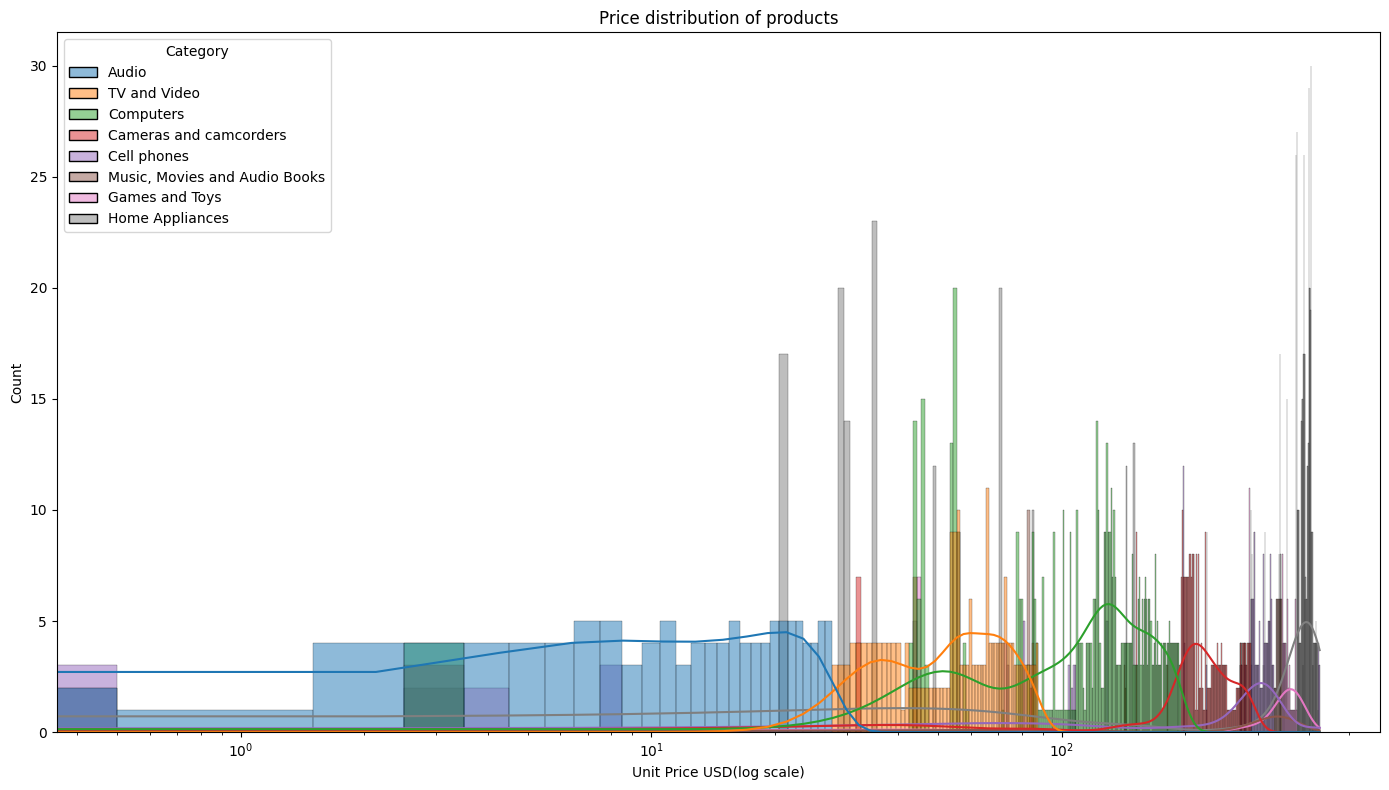

In [ ]:
#1.	Visualize the price distribution of products for each category.
df_products.columns
plt.figure(figsize=(14,8))
sns.histplot(data=df_products, 
             x='Unit Price USD',
             hue='Category',
             bins=30,
             kde=True)
plt.title('Price distribution of products')
plt.xlabel('Unit Price USD(log scale)')
plt.xscale('log')
plt.tight_layout()
plt.show()





In [15]:
# filtering nulls
df_products['Brand']=df_products['Brand'].fillna(df_products['Brand'].mode()[0])
df_customers['State Code']=df_customers['State Code'].fillna(df_customers['State Code'].mode()[0])
df_customers['State Code'].isnull().sum()
df_sales['Delivery Date']=df_sales['Delivery Date'].fillna(df_sales['Delivery Date'].mode()[0])
df_stores['Square Meters']=df_stores['Square Meters'].fillna(df_stores['Square Meters'].mean())








In [94]:
df_customers['State Code']=df_customers['State Code'].fillna(df_customers['State Code'].mode()[0])
df_customers['State Code'].isnull().sum()


np.int64(0)

In [121]:
df_exchange.isnull().sum()

Date        0
Currency    0
Exchange    0
dtype: int64

In [122]:
df_sales['Delivery Date']=df_sales['Delivery Date'].fillna(df_sales['Delivery Date'].mode()[0])
df_sales.isnull().sum()

Order Number     0
Line Item        0
Order Date       0
Delivery Date    0
CustomerKey      0
StoreKey         0
ProductKey       0
Quantity         0
Currency Code    0
dtype: int64

In [123]:
df_stores['Square Meters']=df_stores['Square Meters'].fillna(df_stores['Square Meters'].mean())
df_stores.isnull().sum()

StoreKey         0
Country          0
State            0
Square Meters    0
Open Date        0
dtype: int64

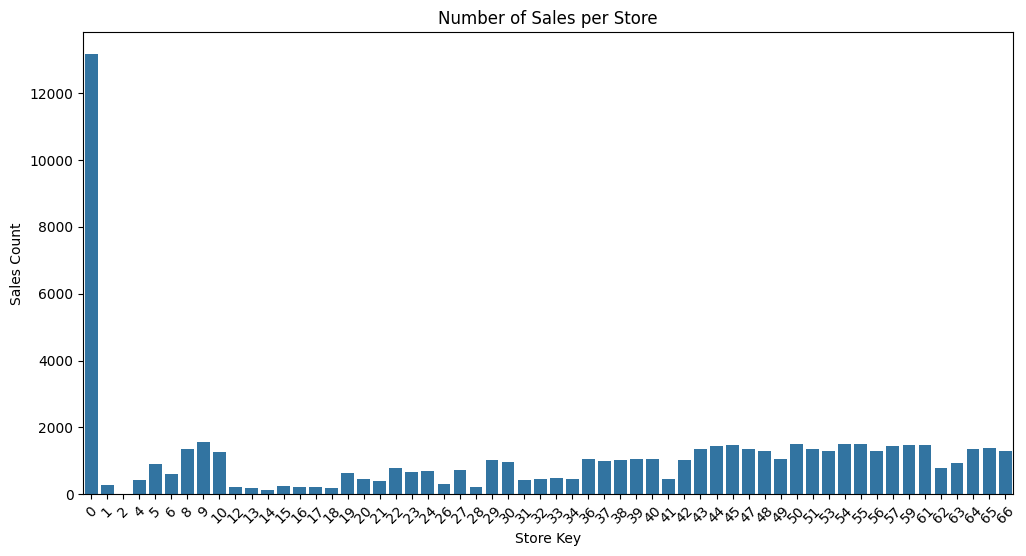

In [ ]:
#2.	Create a bar plot showing the number of sales for each store.
store_sales = df_sales.groupby('StoreKey')['Order Number'].count().reset_index(name='Sales_Count')
plt.figure(figsize=(12,6))
sns.barplot(data=store_sales, x='StoreKey', y='Sales_Count')

plt.title('Number of Sales per Store')
plt.xlabel('Store Key')
plt.ylabel('Sales Count')
plt.xticks(rotation=45)
plt.show()

In [7]:
for cat in categories:
    group = df_products[df_products['CategoryKey'] == cat]['Unit Price USD']
    print(cat, "-> number of samples:", len(group))

In [8]:
df_products =pd.read_csv('./Products.csv')

In [ ]:
#3 Display all prices in the Sales table in USD.
df_sales = pd.read_csv('./Sales.csv')
df_products = pd.read_csv('./Products.csv')

df = df_sales.merge(df_products, on='ProductKey')
df['Sales_USD'] = df['Quantity'] * df['Unit Price USD']
df[['ProductKey','Quantity','Unit Price USD','Sales_USD']].head()

,ProductKey,Quantity,Unit Price USD,Sales_USD
0,1304,1,$68.00,$68.00
1,1048,2,$427.00,$427.00 $427.00
2,2007,1,$665.94,$665.94
3,1106,7,$322.00,$322.00 $322.00 $322.00 $322.00 $322.00 $322.0...
4,373,1,$326.00,$326.00


In [20]:
df_products = pd.read_csv('products.csv')
print(df_products.head())
print(df_products.shape)

   ProductKey                         Product Name    Brand   Color  \
0           1  Contoso 512MB MP3 Player E51 Silver  Contoso  Silver   
1           2    Contoso 512MB MP3 Player E51 Blue  Contoso    Blue   
2           3     Contoso 1G MP3 Player E100 White  Contoso   White   
3           4    Contoso 2G MP3 Player E200 Silver  Contoso  Silver   
4           5       Contoso 2G MP3 Player E200 Red  Contoso     Red   

  Unit Cost USD Unit Price USD  SubcategoryKey Subcategory  CategoryKey  \
0        $6.62         $12.99              101     MP4&MP3            1   
1        $6.62         $12.99              101     MP4&MP3            1   
2        $7.40         $14.52              101     MP4&MP3            1   
3       $11.00         $21.57              101     MP4&MP3            1   
4       $11.00         $21.57              101     MP4&MP3            1   

  Category  
0    Audio  
1    Audio  
2    Audio  
3    Audio  
4    Audio  
(2517, 10)


In [23]:
df_products['Unit Price USD'] = pd.to_numeric(
    df_products['Unit Price USD']
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip(),
    errors='coerce'
)

In [24]:
print(df_products['Unit Price USD'].head())
print(df_products['Unit Price USD'].dtype)
print(df_products['Unit Price USD'].isna().sum())

0    12.99
1    12.99
2    14.52
3    21.57
4    21.57
Name: Unit Price USD, dtype: float64
float64
0


In [25]:
df = df_sales.merge(
    df_products[['ProductKey', 'Brand', 'Unit Price USD']],
    on='ProductKey',
    how='left'
)

In [ ]:
# 4 Analyze the mean and standard deviation of sales across different brands.
df['Sales_USD'] = df['Quantity'] * df['Unit Price USD']

brand_stats = df.groupby('Brand')['Sales_USD'].agg(['mean', 'std'])

print(brand_stats)

                             mean          std
Brand                                         
A. Datum               810.364122   780.377956
Adventure Works       1856.770498  2349.836247
Contoso                676.507573  1486.469728
Fabrikam              1912.329640  2571.586001
Litware               1599.217547  2963.202469
Northwind Traders      467.054973  1624.955799
Proseware             1072.663780  1912.766785
Southridge Video       326.942555   556.877295
Tailspin Toys          125.111041   199.731628
The Phone Company      888.620917   713.526937
Wide World Importers  1056.774241  1531.788053


<Figure size 1500x800 with 0 Axes>

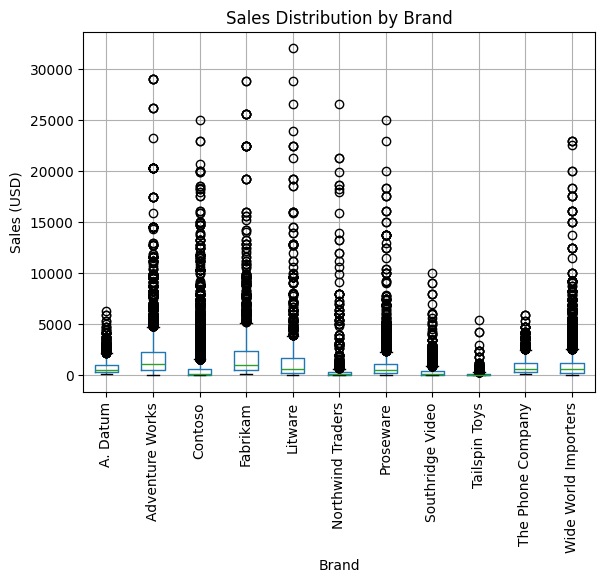

In [ ]:
#5.Analyze the mean and standard deviation of sales across different brands. Determine whether there are any outliers.
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

df.boxplot(
    column='Sales_USD',
    by='Brand',
    rot=90
)

plt.title('Sales Distribution by Brand')
plt.suptitle('')
plt.xlabel('Brand')
plt.ylabel('Sales (USD)')

plt.show()